## Projeto para predizer a saida de clientes do banco

A base de dados utilizada está disponível no kaggle: 
https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers/data

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score, accuracy_score

import plotly.express as px
import matplotlib.pyplot as plot
import plotly.express as px


In [26]:
# carregando os dados
data = pd.read_csv('churn.csv')
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [27]:
# verificando os tipos dos dados
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [28]:
# verifico se existem valores null em minha base
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Entendimento dos dados

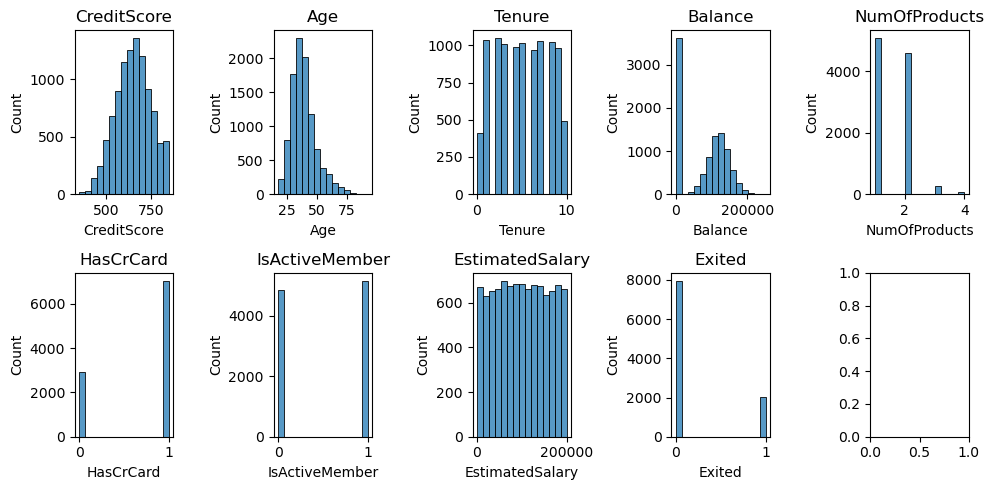

In [29]:
# Definir tamanho da figura
# Ajuste conforme o número de colunas
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))
axes = axes.flatten()  # Achatar a matriz de eixos para facilitar a iteração

# Iterar sobre cada coluna numérica e criar um histograma
for i, col in enumerate(data.select_dtypes(include=["number"]).columns):
    if i > 1:
        sns.histplot(data[col], bins=15, ax=axes[i-2], kde=False)
        axes[i-2].set_title(col)

# Ajustar layout para evitar sobreposição
plt.tight_layout()
plt.show()

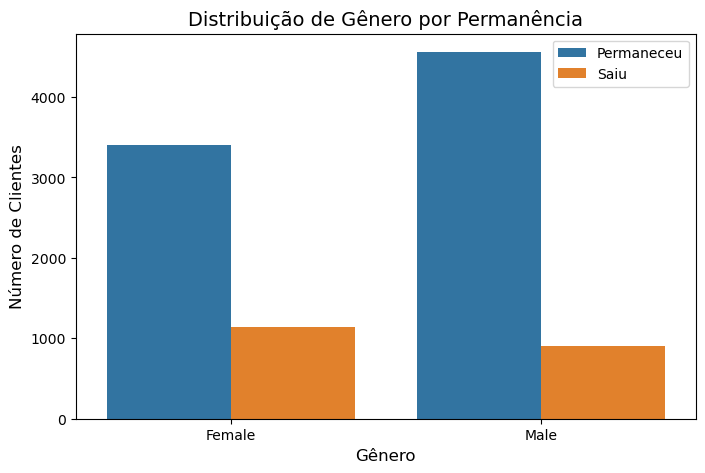

In [30]:
# Criando o gráfico de barras com Seaborn
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=data, x="Gender", hue="Exited")

# Adicionando rótulos e título
plt.title("Distribuição de Gênero por Permanência", fontsize=14)
plt.xlabel("Gênero", fontsize=12)
plt.ylabel("Número de Clientes", fontsize=12)
plt.xticks(rotation=0)

# Adicionando legenda
plt.legend(labels=["Permaneceu", "Saiu"])

# Exibir o gráfico
plt.show()

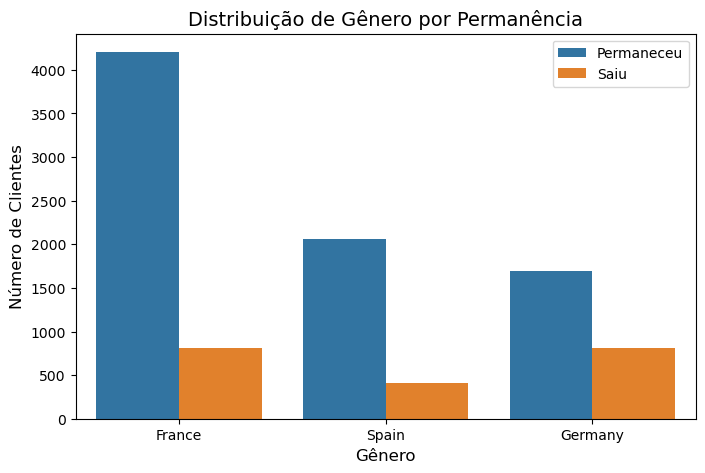

In [31]:
# Criando o gráfico de barras com Seaborn
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=data, x="Geography", hue="Exited")

# Adicionando rótulos e título
plt.title("Distribuição de Gênero por Permanência", fontsize=14)
plt.xlabel("Gênero", fontsize=12)
plt.ylabel("Número de Clientes", fontsize=12)
plt.xticks(rotation=0)

# Adicionando legenda
plt.legend(labels=["Permaneceu", "Saiu"])

# Exibir o gráfico
plt.show()

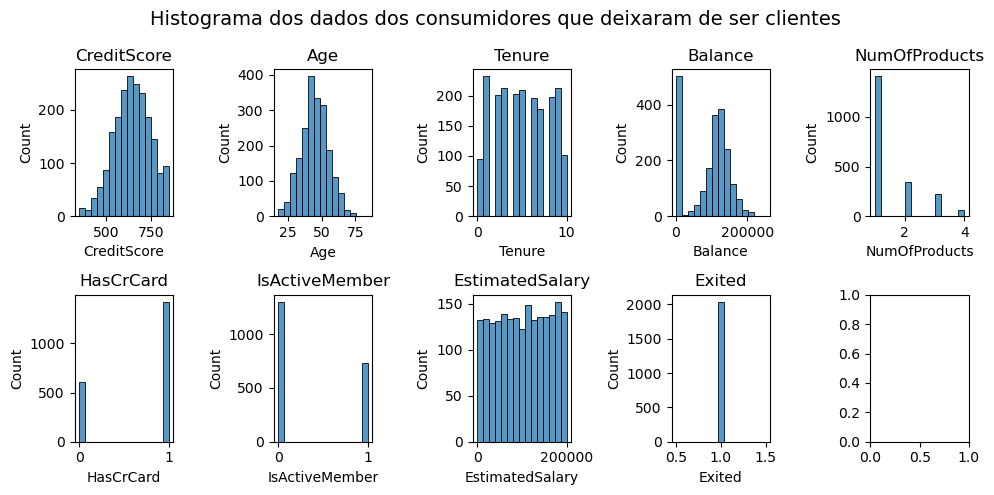

In [32]:
# Histograma dos dados dos consumidores que deixaram de ser clientes
df_filtrado = data[data['Exited'] == 1]

# Definir tamanho da figura
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))  # Ajuste conforme o número de colunas
axes = axes.flatten()  # Achatar a matriz de eixos para facilitar a iteração
# Iterar sobre cada coluna numérica e criar um histograma
for i, col in enumerate(df_filtrado.select_dtypes(include=["number"]).columns):
    if i > 1:
        sns.histplot(df_filtrado[col], bins=15, ax=axes[i-2], kde=False)
        axes[i-2].set_title(col)

fig.suptitle("Histograma dos dados dos consumidores que deixaram de ser clientes", fontsize=14)


# Ajustar layout para evitar sobreposição
plt.tight_layout()

plt.show()

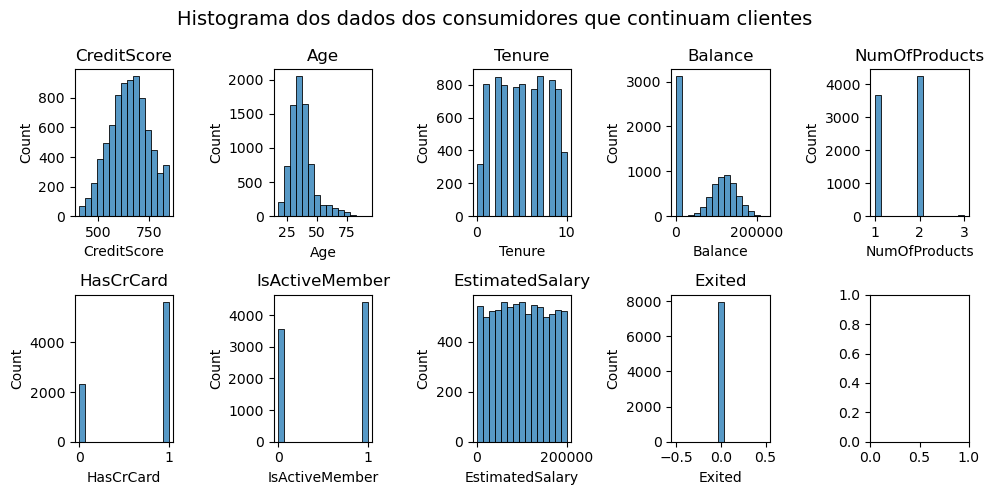

In [33]:
# Histograma dos dados dos consumidores que permaneceram clientes

df_filtrado = data[data['Exited'] == 0]

# Definir tamanho da figura
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))  # Ajuste conforme o número de colunas
axes = axes.flatten()  # Achatar a matriz de eixos para facilitar a iteração

# Iterar sobre cada coluna numérica e criar um histograma
for i, col in enumerate(df_filtrado.select_dtypes(include=["number"]).columns):
    if i > 1:
        sns.histplot(df_filtrado[col], bins=15, ax=axes[i-2], kde=False)
        axes[i-2].set_title(col)

fig.suptitle("Histograma dos dados dos consumidores que continuam clientes", fontsize=14)

# Ajustar layout para evitar sobreposição
plt.tight_layout()
plt.show()

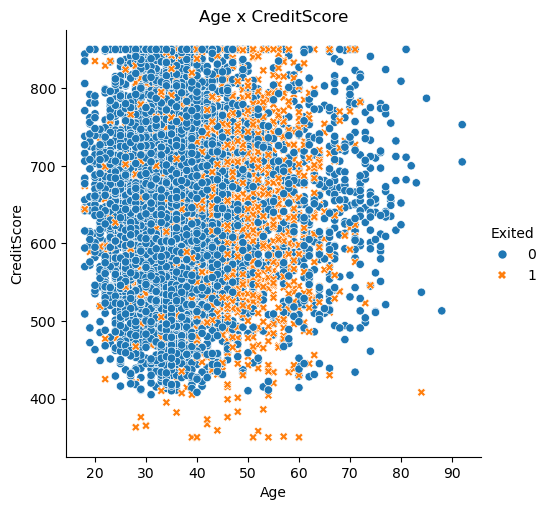

In [34]:
g = sns.relplot(
    data=data,
    x="Age", y="CreditScore", hue="Exited", style="Exited"
)
plt.title("Age x CreditScore")
plt.show()

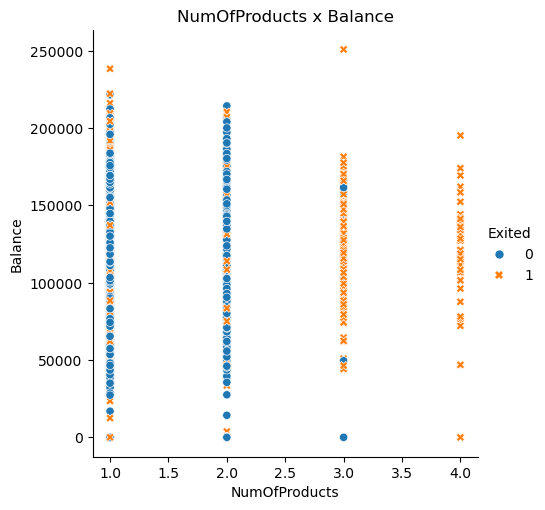

In [35]:
sns.relplot(
    data=data,
    x="NumOfProducts", y="Balance", hue="Exited", style="Exited"
)

plt.title("NumOfProducts x Balance")
plt.show()

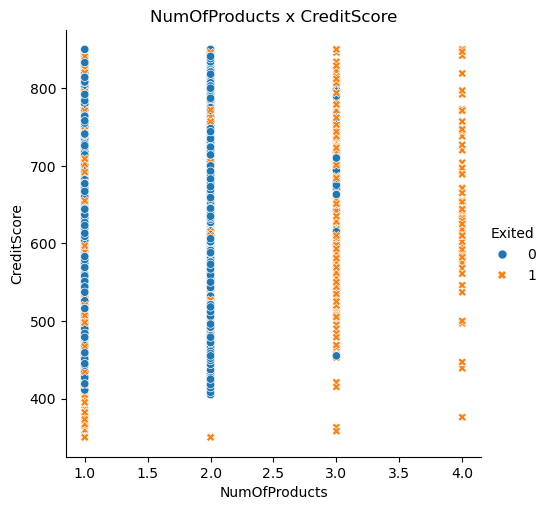

In [36]:
sns.relplot(
    data=data,
    x="NumOfProducts", y="CreditScore", hue="Exited", style="Exited"
)

plt.title("NumOfProducts x CreditScore")
plt.show()

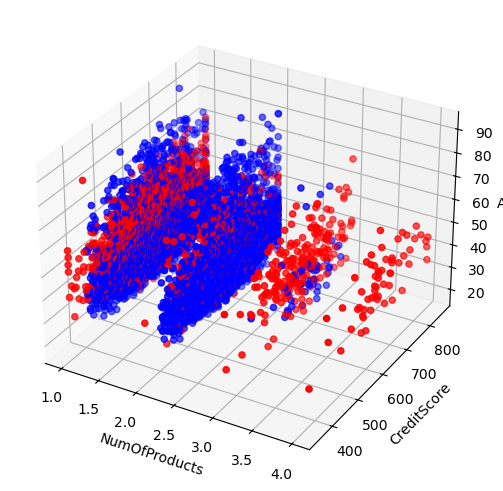

In [37]:
plot.figure(figsize=(6, 5))
seaborn_plot = plt.axes(projection='3d')
colors = np.where(data["Exited"] == 0, 'b', 'r')
seaborn_plot.scatter3D(data["NumOfProducts"], data["CreditScore"],
                       data["Age"], c=colors)
seaborn_plot.set_xlabel('NumOfProducts')
seaborn_plot.set_ylabel('CreditScore')
seaborn_plot.set_zlabel('Age')

plot.tight_layout()
plot.show()

In [38]:
fig = px.scatter_3d(data, x='NumOfProducts', y='CreditScore', z='Age',
                    color='Exited', color_continuous_scale='Viridis',
                    title="Gráfico 3D Interativo", opacity=1)

fig.update_traces(marker_size=3)

# Exibindo o gráfico interativo
fig.show()

In [39]:
# Vamos criar novos atributos com as colunas Gender e Geography
data = pd.get_dummies(data = data ,columns=['Gender', 'Geography'])
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,True,False,True,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,True,False,False,False,True
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,True,False,True,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,True,False,True,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,True,False,False,False,True


In [40]:
# Retirando dados que não serão utilizados para a predição
data.drop("CustomerId", axis=1, inplace=True)
data.drop("Surname", axis=1, inplace=True)
data.drop("RowNumber", axis=1, inplace=True)
data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,True,False,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,True,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,True,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,True,False,False,False,True


<Axes: >

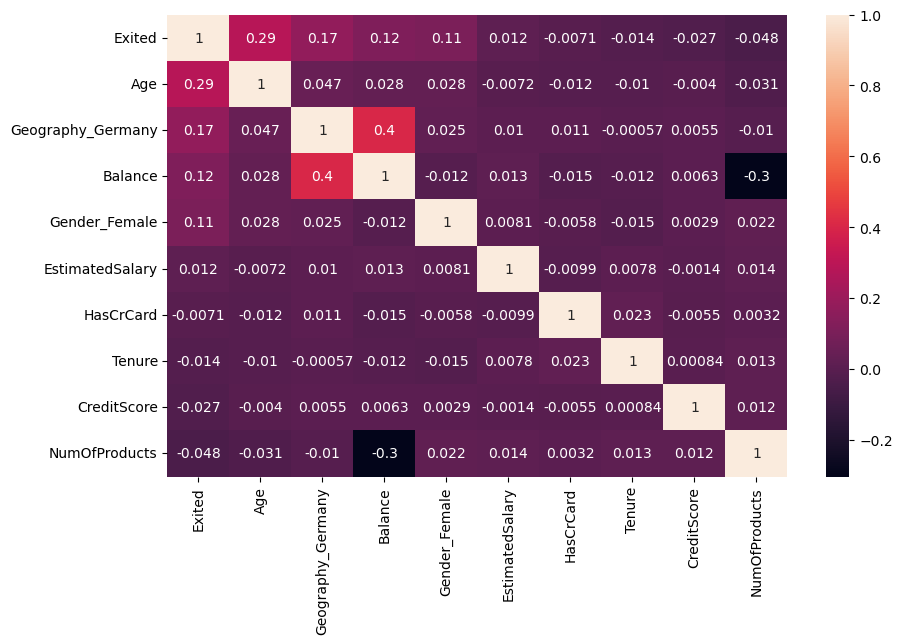

In [41]:
# Exibir a matriz de correlação com o nosso objetivo: Exited
k = 10 #número de linhas/colunas heatmap
cols = data.corr().nlargest(k, 'Exited')['Exited'].index
cm = data[cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True)

## Predição

In [42]:
x = data.drop(['Exited'], axis=1)
y = data['Exited']

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1,
                                                    random_state=200)

In [44]:
# Criação do modelo com o Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf_fit = rf.fit(x_train, y_train)
rf_train = rf_fit.predict(x_train)
rf_test = rf_fit.predict(x_test)

# metricas para avaliação do modelo
print('Treino')
print('Acurárica : ' +str(accuracy_score(rf_train, y_train)))
print('F1 : '+str(f1_score(rf_train, y_train)))
print('ROC AUC : ' +str(roc_auc_score(y_train, rf_fit.predict_proba(x_train)[::,1])))

print('\n')

print('Teste')
print('Acurácia :' + str(accuracy_score(rf_test, y_test)))
print('F1 : '+str((f1_score(rf_test, y_test))))
print('ROC AUC : ' + str((roc_auc_score(y_test, rf_fit.predict_proba(x_test)[::,1]))))

print('\n')
print('Matrix de Confusão')
confusion_matrix(y_test, rf_fit.predict(x_test))

Treino
Acurárica : 1.0
F1 : 1.0
ROC AUC : 1.0


Teste
Acurácia :0.855
F1 : 0.5592705167173252
ROC AUC : 0.82720766928449


Matrix de Confusão


array([[763,  43],
       [102,  92]])

## Balanceando a base de dados

In [45]:
# Número de clientes que saíram
Exited_records = data['Exited'].sum()

# Índices de clientes que saíram
Exited_indices = data.index[data['Exited'] == 1].to_numpy()

# Índices de clientes que permaneceram
normal_indices = data.index[data['Exited'] == 0].to_numpy()

# Seleção aleatória de clientes que permaneceram (mesma quantidade dos que saíram)
random_normal_indices = np.random.choice(normal_indices, Exited_records, replace=False)

# Combinação dos índices para o undersampling
under_sample_indices = np.hstack([Exited_indices, random_normal_indices])

# Criando o dataset balanceado
under_sample_data = data.loc[under_sample_indices]

# Separação em features e target
features_undersample = under_sample_data.drop(columns=['Exited'])
target_undersample = under_sample_data['Exited']

In [46]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(features_undersample,
                                                            target_undersample,
                                                            test_size=0.05,
                                                            random_state=25)

In [48]:
# Criação do modelo com o Random Forest com os dados balanceados
rf = RandomForestClassifier(n_estimators=100)
rf_fit_s = rf.fit(X_train_s, y_train_s)
rf_train_s = rf_fit_s.predict(X_train_s)
rf_test_s = rf_fit_s.predict(X_test_s)

# metricas para avaliação do modelo
print('Treino')
print('Acurárica : ' +str(accuracy_score(rf_train_s, y_train_s)))
print('F1 : '+str(f1_score(rf_train_s, y_train_s)))
print('ROC AUC : ' +str(roc_auc_score(y_train_s, rf_fit_s.predict_proba(X_train_s)[::,1])))

print('\n')

print('Teste')
print('Acurácia :' + str(accuracy_score(rf_test_s, y_test_s)))
print('F1 : '+str((f1_score(rf_test_s, y_test_s))))
print('ROC AUC : ' + str((roc_auc_score(y_test_s, rf_fit_s.predict_proba(X_test_s)[::,1]))))

print('\n')
print('Matrix de Confusão')
confusion_matrix(y_test_s, rf_fit_s.predict(X_test_s))

Treino
Acurárica : 1.0
F1 : 1.0
ROC AUC : 1.0


Teste
Acurácia :0.7598039215686274
F1 : 0.7699530516431925
ROC AUC : 0.8411515908872441


Matrix de Confusão


array([[73, 28],
       [21, 82]])

## Treinado com a base balanceada e testado com toda a base

In [51]:
rf_train_s_s = rf_fit_s.predict(x_train)
rf_test_s_s = rf_fit_s.predict(x_test)

# metricas para avaliação do modelo
print('Treino')
print('Acurárica : ' +str(accuracy_score(rf_train_s_s, y_train)))
print('F1 : '+str(f1_score(rf_train_s_s, y_train)))
print('ROC AUC : ' +str(roc_auc_score(y_train, rf_fit_s.predict_proba(x_train)[::,1])))

print('\n')

print('Teste')
print('Acurácia :' + str(accuracy_score(rf_test_s_s, y_test)))
print('F1 : '+str((f1_score(rf_test_s_s, y_test))))
print('ROC AUC : ' + str((roc_auc_score(y_test, rf_fit_s.predict_proba(x_test)[::,1]))))

print('\n')
print('Matrix de Confusão')
confusion_matrix(y_test, rf_fit_s.predict(x_test))

Treino
Acurárica : 0.8721111111111111
F1 : 0.7600583698144674
ROC AUC : 0.9817453682619969


Teste
Acurácia :0.853
F1 : 0.724202626641651
ROC AUC : 0.9749238955258244


Matrix de Confusão


array([[660, 146],
       [  1, 193]])

Conclusão: com uma base desbalanceada a predição poderá ficar prejudicada, porém se o treinamento do modelo for realizada em uma base balanceada e testar o modelo com a base desbalanceada, o modelo poderá performar melhor, como foi o caso.